# Regression for Large Matrices with Joint Column and Row Reduction

## 1. Setup of Notebook

In [ ]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

from pathlib import Path
import warnings
from screening_analysis import *
from visualizations import *
import pickle
import copy
import numpy as np

# eliminate warnings for the linear modeling without column names
warnings.filterwarnings(action='ignore', category=UserWarning)

In [ ]:
#==============================================================================================
# Setting the base path of the data folders
#==============================================================================================
base = Path("/Users/timschmale/Documents/GIT/Masterthesis")

In [ ]:
#==============================================================================================
# Setting if study should be performed or the results should be loaded from storage
#==============================================================================================
def save_results(filename, **kwargs):
    with open(filename, "wb") as f:
        pickle.dump(kwargs, f)

def load_results(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

In [ ]:
def combine_seed_results(base_path, save_name=None):
    """
    Combine all per-seed result pickle files into a single results dictionary
    that matches the structure produced by save_results().
    """

    combined = {}

    # find all seed files
    seed_files = sorted([
        f for f in os.listdir(base_path)
        if f.endswith(".pkl") and "seed" in f
    ])

    print(f"Found {len(seed_files)} seed files.")

    # load each seed file
    for fname in seed_files:
        seed_number = int(fname.split("_seed_")[1].split(".")[0])
        full_path = os.path.join(base_path, fname)

        with open(full_path, "rb") as f:
            combined[seed_number] = pickle.load(f)

        print(f"Loaded seed {seed_number} from {fname}")

    # wrap in "results" to match save_results() structure
    wrapped = {"results": combined}

    # optionally save combined file
    if save_name is not None:
        save_path = os.path.join(base_path, save_name)
        with open(save_path, "wb") as f:
            pickle.dump(wrapped, f)
        print(f"Saved combined results → {save_path}")

    return wrapped

In [ ]:
# setting the k values
k_vector = [10,20,25,50,100,200,300,400,500]

reps = 10

## 2. Row Reduction After Column Reduction Analysis

### 2.1. p = 1.000 and n = 1.000

#### 2.1.1. Data Reduction for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 1.000, n = 1.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p1000_n1000"
results_folder = "Results/column_row/p1000_n1000"

combined = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_cr_p1000_n1000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_cr_p1000_n1000_combined.pkl"
)

results_1000_cr = loaded["results"]

print("Data load completed.")

#### 2.1.2. RMSE Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_cr, k_vector, dataset="1000", metric="rmse", aggregate="median", save_path="plots/rmse/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_cr, k_vector, dataset="1000", metric="rmse_train", aggregate="median", save_path="plots/rmse/column_row")

#### 2.1.3. Time Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_cr, k_vector, dataset="1000", metric="time_scores", aggregate="median", save_path="plots/time/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_cr, k_vector, dataset="1000", metric="time_model", aggregate="median", save_path="plots/time/column_row")

#### 2.1.4. Screening Performance for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 1.000 and n = 1.000
#==============================================================================================
df_screen = collect_screening_results(
    results_1000_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, dataset="1000", save_path="plots/screening/column_row", metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, dataset="1000", save_path="plots/screening/column_row", metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_1000_cr, k_vector)

### 2.2. p = 5.000 and n = 5.000

#### 2.2.1. Data Reduction for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 5.000, n = 5.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p5000_n5000"
results_folder = "Results/column_row/p5000_n5000"

combined2 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_cr_p5000_n5000_combined.pkl"
)
print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_cr_p5000_n5000_combined.pkl"
)

results_5000_cr = loaded["results"]

print("Data load completed.")

#### 2.2.2. RMSE Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: RMSE Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_cr, k_vector, metric="rmse", dataset="5000", aggregate="median", save_path="plots/rmse/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: RMSE Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_cr, k_vector, metric="rmse_train", dataset="5000", aggregate="median", save_path="plots/rmse/column_row")

#### 2.2.3. Time Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_cr, k_vector, metric="time_scores", dataset="5000", aggregate="median", save_path="plots/time/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_cr, k_vector, metric="time_model", dataset="5000", aggregate="median", save_path="plots/time/column_row")

#### 2.2.4. Screening Performance for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 5.000 and n = 5.000
#==============================================================================================
df_screen = collect_screening_results(
    results_5000_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, dataset="5000", save_path="plots/screening/column_row", metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, dataset="5000", save_path="plots/screening/column_row", metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_5000_cr, k_vector)

### 2.3. Analysis for p = 10.000 and n = 10.000

#### 2.3.1. Data Reduction for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 10.000, n = 10.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p10000_n10000"
results_folder = "Results/column_row/p10000_n10000"

combined3 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_cr_p10000_n10000_combined.pkl"
)
print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_cr_p10000_n10000_combined.pkl"
)

results_10000_cr = loaded["results"]

print("Data load completed.")

#### 2.3.2. RMSE Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 10.000 and n = 10.000
#==============================================================================================
plot_all_boxplots(results_10000_cr, k_vector, metric="rmse", dataset="10000", aggregate="median", save_path="plots/rmse/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 10.000 and n = 10.000
#==============================================================================================
plot_all_boxplots(results_10000_cr, k_vector, metric="rmse_train", dataset="10000", aggregate="median", save_path="plots/rmse/column_row")

#### 2.3.3. Time Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_cr, k_vector, metric="time_scores", dataset="10000", aggregate="median", save_path="plots/time/column_row")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_cr, k_vector, metric="time_model", dataset="10000", aggregate="median", save_path="plots/time/column_row")

#### 2.3.4. Screening Performance for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 10.000 and n = 10.000
#==============================================================================================
df_screen = collect_screening_results(
    results_10000_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, dataset="10000", save_path="plots/screening/column_row", metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, dataset="10000", save_path="plots/screening/column_row", metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_10000_cr, k_vector)

## 3. Column Reduction without Row Reduction Analysis

### 3.1. p = 1.000 and n = 1.000

#### 3.1.1. Data Reduction for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 1.000, n = 1.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p1000_n1000"
results_folder = "Results/column_only/p1000_n1000"

combined4 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_no_rr_p1000_n1000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_no_rr_p1000_n1000_combined.pkl"
)

results_1000_no_rr = loaded["results"]

print("Data load completed.")

#### 3.1.2. RMSE Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_no_rr, k_vector, dataset="1000", metric="rmse", aggregate="median", save_path="plots/rmse/column_only")

#### 3.1.3. Time Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_no_rr, k_vector, dataset="1000", metric="time_scores", aggregate="median", save_path="plots/time/column_only")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_no_rr, k_vector, dataset="1000", metric="time_model", aggregate="median", save_path="plots/time/column_only")

#### 3.1.4. Screening Performance for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 1.000 and n = 1.000
#==============================================================================================
df_screen = collect_screening_results(
    results_1000_no_rr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw", dataset="1000")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw", dataset="1000")

In [ ]:
plot_dimension_facets(results_1000_no_rr, k_vector)

### 3.2. p = 5.000 and n = 5.000

#### 3.2.1. Data Reduction for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 5.000, n = 5.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p5000_n5000"
results_folder = "Results/column_only/p5000_n5000"

combined5 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_no_rr_p5000_n5000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_no_rr_p5000_n5000_combined.pkl"
)

results_5000_no_rr = loaded["results"]

print("Data load completed.")

#### 3.2.2. RMSE Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_no_rr, k_vector, dataset="5000", metric="rmse", aggregate="median", save_path="plots/rmse/column_only")

#### 3.2.3. Time Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_no_rr, k_vector, dataset="5000", metric="time_scores", aggregate="median", save_path="plots/time/column_only")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_no_rr, k_vector, dataset="5000", metric="time_model", aggregate="median", save_path="plots/time/column_only")

#### 3.2.4. Screening Performance for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 5.000 and n = 5.000
#==============================================================================================
df_screen = collect_screening_results(
    results_5000_no_rr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw", dataset="5000")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw", dataset="5000")

In [ ]:
plot_dimension_facets(results_5000_no_rr, k_vector)

### 3.3. p = 10.000 and n = 10.000

#### 3.3.1. Data Reduction for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 10.000, n = 10.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p10000_n10000"
results_folder = "Results/column_only/p10000_n10000"

combined6 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_no_rr_p10000_n10000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_no_rr_p10000_n10000_combined.pkl"
)

results_10000_no_rr = loaded["results"]

print("Data load completed.")

#### 3.3.2. RMSE Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 10.000 and n = 10.000
#==============================================================================================
plot_all_boxplots(results_10000_no_rr, k_vector, dataset="10000", metric="rmse", aggregate="median", save_path="plots/rmse/column_only")

#### 3.3.3. Time Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_all_boxplots(results_10000_no_rr, k_vector, dataset="10000", metric="time_scores", aggregate="median", save_path="plots/rmse/column_only")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_all_boxplots(results_10000_no_rr, k_vector, dataset="10000", metric="time_model", aggregate="median", save_path="plots/rmse/column_only")

#### 3.3.4. Screening Performance for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 10.000 and n = 10.000
#==============================================================================================
df_screen = collect_screening_results(
    results_10000_no_rr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw", dataset="10000")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw", dataset="10000")

In [ ]:
plot_dimension_facets(results_10000_no_rr, k_vector)

## 4. Column Reduction After Row Reduction Analysis

### 4.1. Analysis for p = 1.000 and n = 1.000

#### 4.1.1. Data Reduction for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 1.000, n = 1.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p1000_n1000"
results_folder = "Results/row_column/p1000_n1000"

combined7 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_rc_p1000_n1000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_rc_p1000_n1000_combined.pkl"
)

results_1000_rc = loaded["results"]

print("Data load completed.")

#### 4.1.2. RMSE Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_rc, k_vector, dataset="1000", metric="rmse", aggregate="median", save_path="plots/rmse/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_rc, k_vector, dataset="1000", metric="rmse_train", aggregate="median", save_path="plots/rmse/row_column")

#### 4.1.3. Time Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Time for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_rc, k_vector, dataset="1000", metric="time_scores", aggregate="median", save_path="plots/time/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Time for p = 1.000 and n = 1.000
#==============================================================================================
plot_all_boxplots(results_1000_rc, k_vector, dataset="1000", metric="time_model", aggregate="median", save_path="plots/time/row_column")

#### 4.1.4. Screening Performance for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 1.000 and n = 1.000
#==============================================================================================

df_screen = collect_screening_results(
    results_1000_rc,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw", dataset="1000")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw", dataset="1000")

In [ ]:
plot_dimension_facets(results_1000_rc, k_vector)

### 4.2. Analysis for p = 5.000 and n = 5.000

#### 4.2.1. Data Reduction for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 5.000, n = 5.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p5000_n5000"
results_folder = "Results/row_column/p5000_n5000"

combined8 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_rc_p5000_n5000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_rc_p5000_n5000_combined.pkl"
)

results_5000_rc = loaded["results"]

print("Data load completed.")

#### 4.2.2. RMSE Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_rc, k_vector, dataset="5000", metric="rmse", aggregate="median", save_path="plots/rmse/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_rc, k_vector, dataset="5000", metric="rmse_train", aggregate="median", save_path="plots/rmse/row_column")

#### 4.2.3. Time Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_rc, k_vector, dataset="5000", metric="time_scores", aggregate="median", save_path="plots/time/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_all_boxplots(results_5000_rc, k_vector, dataset="5000", metric="time_model", aggregate="median", save_path="plots/time/row_column")

#### 4.2.4. Screening Performance for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 5.000 and n = 5.000
#==============================================================================================

df_screen = collect_screening_results(
    results_5000_rc,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_5000_rc, k_vector)

### 4.3. Analysis for p = 10.000 and n = 10.000

#### 4.3.1. Data Reduction for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 10.000, n = 10.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p10000_n10000"
results_folder = "Results/row_column/p10000_n10000"

combined9 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_rc_p10000_n10000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_rc_p10000_n10000_combined.pkl"
)

results_10000_rc = loaded["results"]

print("Data load completed.")

#### 4.3.2. RMSE Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_rc, k_vector, dataset="10000", metric="rmse", aggregate="median", save_path="plots/rmse/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of RMSE for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_rc, k_vector, dataset="10000", metric="rmse_train", aggregate="median", save_path="plots/rmse/row_column")

#### 4.3.3. Time Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_rc, k_vector, dataset="10000", metric="time_scores", aggregate="median", save_path="plots/time/row_column")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_rc, k_vector, dataset="10000", metric="time_model", aggregate="median", save_path="plots/time/row_column")

#### 4.3.4. Screening Performance for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 10.000 and n = 10.000
#==============================================================================================

df_screen = collect_screening_results(
    results_10000_rc,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_10000_rc, k_vector)

## 5. Logistic Regression: Column Reduction After Row Reduction Analysis

### 5.1. Analysis for p = 1.000 and n = 1.000

#### 5.1.1. Data Reduction for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 1.000, n = 1.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p1000_n1000"
results_folder = "Results/log_reg/p1000_n1000"

combined10 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_log_reg_cr_p1000_n1000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_log_reg_cr_p1000_n1000_combined.pkl"
)

results_1000_log_reg_cr = loaded["results"]

print("Data load completed.")

#### 5.1.2. Brier Score Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 1.000 and n = 1.000
#==============================================================================================
plot_facets_all_seeds(results_1000_log_reg_cr, k_vector, dataset="1000", metric="brier", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 1.000 and n = 1.000
#==============================================================================================
plot_facets_all_seeds(results_1000_log_reg_cr, k_vector, dataset="1000", metric="ce", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 1.000 and n = 1.000
#==============================================================================================
plot_facets_all_seeds(results_1000_log_reg_cr, k_vector, dataset="1000", metric="ce_train", aggregate="median", save_path="plots/brier")

#### 5.1.3. Time Analysis for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 1.000 and n = 1.000
#==============================================================================================
plot_facets_all_seeds(results_1000_log_reg_cr, k_vector, dataset="1000", metric="time_scores", aggregate="median", save_path="plots/time/log_reg")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 1.000 and n = 1.000
#==============================================================================================
plot_facets_all_seeds(results_1000_log_reg_cr, k_vector, dataset="1000", metric="time_model", aggregate="median", save_path="plots/time/log_reg")

#### 5.1.4. Screening Performance for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 1.000 and n = 1.000
#==============================================================================================

df_screen = collect_screening_results(
    results_1000_log_reg_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_1000_log_reg_cr, k_vector)

### 5.2. Analysis for p = 5.000 and n = 5.000

#### 5.2.1. Data Reduction for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 5.000, n = 5.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p5000_n5000"
results_folder = "Results/log_reg/p5000_n5000"

combined11 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_log_reg_cr_p5000_n5000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_log_reg_cr_p5000_n5000_combined.pkl"
)

results_5000_log_reg_cr = loaded["results"]

print("Data load completed.")

#### 5.2.2. Brier Score Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 5.000 and n = 5.000
#==============================================================================================
plot_facets_all_seeds(results_5000_log_reg_cr, k_vector, dataset="5000", metric="brier", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 5.000 and n = 5.000
#==============================================================================================
plot_facets_all_seeds(results_5000_log_reg_cr, k_vector, dataset="5000", metric="ce", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 5.000 and n = 5.000
#==============================================================================================
plot_facets_all_seeds(results_5000_log_reg_cr, k_vector, dataset="5000", metric="ce_train", aggregate="median", save_path="plots/brier")

#### 5.2.3. Time Analysis for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_facets_all_seeds(results_5000_log_reg_cr, k_vector, dataset="5000", metric="time_scores", aggregate="median", save_path="plots/time/log_reg")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 5.000 and n = 5.000
#==============================================================================================
plot_facets_all_seeds(results_5000_log_reg_cr, k_vector, dataset="5000", metric="time_model", aggregate="median", save_path="plots/time/log_reg")

#### 5.2.4. Screening Performance for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 5.000 and n = 5.000
#==============================================================================================

df_screen = collect_screening_results(
    results_5000_log_reg_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_5000_log_reg_cr, k_vector)

### 5.3. Analysis for p = 10.000 and n = 10.000

#### 5.3.1. Data Reduction for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 10.000, n = 10.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p10000_n10000"
results_folder = "Results/log_reg/p10000_n10000"

combined12 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_log_reg_cr_p10000_n10000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_log_reg_cr_p10000_n10000_combined.pkl"
)

results_10000_log_reg_cr = loaded["results"]

print("Data load completed.")

#### 5.3.2. Brier Score Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_log_reg_cr, k_vector, dataset="10000", metric="brier", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_log_reg_cr, k_vector, dataset="10000", metric="ce", aggregate="median", save_path="plots/brier")

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Brier Score for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_log_reg_cr, k_vector, dataset="10000", metric="ce_train", aggregate="median", save_path="plots/brier")

#### 5.3.3. Time Analysis for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_log_reg_cr, k_vector, dataset="10000", metric="time_scores", aggregate="median", save_path="plots/time/log_reg")

In [ ]:
#==============================================================================================
# Simulation Study: Time Comparison for p = 10.000 and n = 10.000
#==============================================================================================
plot_facets_all_seeds(results_10000_log_reg_cr, k_vector, dataset="10000", metric="time_model", aggregate="median", save_path="plots/time/log_reg")

#### 5.3.4. Screening Performance for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 10.000 and n = 10.000
#==============================================================================================

df_screen = collect_screening_results(
    results_10000_log_reg_cr,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_10000_log_reg_cr, k_vector)

## 6. LASSO Analysis

### 6.1. Analysis for p = 1.000 and n = 1.000

#### 6.1.1. Data Reduction for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 1.000, n = 1.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p1000_n1000"
results_folder = "Results/lasso/p1000_n1000"

combined13 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_lasso_p1000_n1000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_lasso_p1000_n1000_combined.pkl"
)

results_1000_lasso = loaded["results"]

print("Data load completed.")

#### 6.1.2. RMSE Analysis for p = 1.000 and n = 1.000

In [ ]:
# Start with RC as the base structure (deep copy to avoid modifying the original)
results_1000_combined = copy.deepcopy(results_1000_rc)

# Insert Lasso methods into the RC structure
for seed in results_1000_lasso:
    for k in k_vector:

        # -----------------------------
        # 1) MERGE LOSS VALUES
        # -----------------------------
        for method, stats in results_1000_lasso[seed][k]["loss"].items():

            method_name = method  # Lasso_* is already unique

            # Create method entry if it does not exist yet
            if method_name not in results_1000_combined[seed][k]["loss"]:
                results_1000_combined[seed][k]["loss"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_1000_combined[seed][k]["loss"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_1000_combined[seed][k]["loss"][method_name]["raw"]
            results_1000_combined[seed][k]["loss"][method_name]["mean"] = float(np.mean(arr))
            results_1000_combined[seed][k]["loss"][method_name]["median"] = float(np.median(arr))

        # -----------------------------
        # 2) MERGE TIME_MODEL VALUES
        # -----------------------------
        # Lasso sometimes has time_model = None → skip safely
        lasso_time = results_1000_lasso[seed][k]["time_model"]

        if lasso_time is None:
            continue  # nothing to merge for this seed/k

        # Ensure RC time_model exists (it always should, but we guard anyway)
        if results_1000_combined[seed][k]["time_model"] is None:
            results_1000_combined[seed][k]["time_model"] = {}

        for method, stats in lasso_time.items():

            method_name = method  # Lasso_* is unique

            # Create method entry if missing
            if method_name not in results_1000_combined[seed][k]["time_model"]:
                results_1000_combined[seed][k]["time_model"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_1000_combined[seed][k]["time_model"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_1000_combined[seed][k]["time_model"][method_name]["raw"]
            results_1000_combined[seed][k]["time_model"][method_name]["mean"] = float(np.mean(arr))
            results_1000_combined[seed][k]["time_model"][method_name]["median"] = float(np.median(arr))


plot_facets_all_seeds(
    results_1000_combined,
    k_vector,
    dataset="1000",
    metric="rmse",
    aggregate="median",
    save_path="plots/rmse/lasso"
)


#### 6.1.3. Time Analysis for p = 1.000 and n = 1.000

In [ ]:
plot_facets_all_seeds(
    results_1000_combined,
    k_vector,
    dataset="1000",
    metric="time_model",
    aggregate="median",
    save_path="plots/time/lasso"
)

#### 6.1.4. Screening Performance for p = 1.000 and n = 1.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 1.000 and n = 1.000
#==============================================================================================

df_screen = collect_screening_results(
    results_1000_combined,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_1000_combined, k_vector)

### 6.2. Analysis for p = 5.000 and n = 5.000

#### 6.2.1. Data Reduction for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 5.000, n = 5.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p5000_n5000"
results_folder = "Results/lasso/p5000_n5000"

combined14 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_lasso_p5000_n5000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_lasso_p5000_n5000_combined.pkl"
)

results_5000_lasso = loaded["results"]

print("Data load completed.")

#### 6.2.2. RMSE Analysis for p = 5.000 and n = 5.000

In [ ]:
# Start with RC as the base structure (deep copy to avoid modifying the original)
results_5000_combined = copy.deepcopy(results_5000_rc)

# Insert Lasso methods into the RC structure
for seed in results_5000_lasso:
    for k in k_vector:

        # -----------------------------
        # 1) MERGE LOSS VALUES
        # -----------------------------
        for method, stats in results_5000_lasso[seed][k]["loss"].items():

            method_name = method  # Lasso_* is already unique

            # Create method entry if it does not exist yet
            if method_name not in results_5000_combined[seed][k]["loss"]:
                results_5000_combined[seed][k]["loss"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_5000_combined[seed][k]["loss"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_5000_combined[seed][k]["loss"][method_name]["raw"]
            results_5000_combined[seed][k]["loss"][method_name]["mean"] = float(np.mean(arr))
            results_5000_combined[seed][k]["loss"][method_name]["median"] = float(np.median(arr))

        # -----------------------------
        # 2) MERGE TIME_MODEL VALUES
        # -----------------------------
        # Lasso sometimes has time_model = None → skip safely
        lasso_time = results_5000_lasso[seed][k]["time_model"]

        if lasso_time is None:
            continue  # nothing to merge for this seed/k

        # Ensure RC time_model exists (it always should, but we guard anyway)
        if results_5000_combined[seed][k]["time_model"] is None:
            results_5000_combined[seed][k]["time_model"] = {}

        for method, stats in lasso_time.items():

            method_name = method  # Lasso_* is unique

            # Create method entry if missing
            if method_name not in results_5000_combined[seed][k]["time_model"]:
                results_5000_combined[seed][k]["time_model"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_5000_combined[seed][k]["time_model"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_5000_combined[seed][k]["time_model"][method_name]["raw"]
            results_5000_combined[seed][k]["time_model"][method_name]["mean"] = float(np.mean(arr))
            results_5000_combined[seed][k]["time_model"][method_name]["median"] = float(np.median(arr))


plot_facets_all_seeds(
    results_5000_combined,
    k_vector,
    dataset="5000",
    metric="rmse",
    aggregate="median",
    save_path="plots/rmse/lasso"
)


#### 6.2.3. Time Analysis for p = 5.000 and n = 5.000

In [ ]:
plot_facets_all_seeds(
    results_5000_combined,
    k_vector,
    dataset="5000",
    metric="time_model",
    aggregate="median",
    save_path="plots/time/lasso"
)

#### 6.2.4. Screening Performance for p = 5.000 and n = 5.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 5.000 and n = 5.000
#==============================================================================================

df_screen = collect_screening_results(
    results_5000_combined,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_5000_combined, k_vector)

### 6.3. Analysis for p = 10.000 and n = 10.000

#### 6.3.1. Data Reduction for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: p = 10.000, n = 10.000, reps = 10
#==============================================================================================

# setting the specific folder:
data_folder = "Simulation Data/p10000_n10000"
results_folder = "Results/lasso/p10000_n10000"

combined15 = combine_seed_results(
    base_path=f"{base}/{results_folder}",
    save_name="results_lasso_p10000_n10000_combined.pkl"
)

print("Loading full results object...")

loaded = load_results(
    f"{base}/{results_folder}/results_lasso_p10000_n10000_combined.pkl"
)

results_10000_lasso = loaded["results"]

print("Data load completed.")

#### 6.3.2. RMSE Analysis for p = 10.000 and n = 10.000

In [ ]:
# Start with RC as the base structure (deep copy to avoid modifying the original)
results_10000_combined = copy.deepcopy(results_10000_rc)

# Insert Lasso methods into the RC structure
for seed in results_10000_lasso:
    for k in k_vector:

        # -----------------------------
        # 1) MERGE LOSS VALUES
        # -----------------------------
        for method, stats in results_10000_lasso[seed][k]["loss"].items():

            method_name = method  # Lasso_* is already unique

            # Create method entry if it does not exist yet
            if method_name not in results_10000_combined[seed][k]["loss"]:
                results_10000_combined[seed][k]["loss"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_10000_combined[seed][k]["loss"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_10000_combined[seed][k]["loss"][method_name]["raw"]
            results_10000_combined[seed][k]["loss"][method_name]["mean"] = float(np.mean(arr))
            results_10000_combined[seed][k]["loss"][method_name]["median"] = float(np.median(arr))

        # -----------------------------
        # 2) MERGE TIME_MODEL VALUES
        # -----------------------------
        # Lasso sometimes has time_model = None → skip safely
        lasso_time = results_10000_lasso[seed][k]["time_model"]

        if lasso_time is None:
            continue  # nothing to merge for this seed/k

        # Ensure RC time_model exists (it always should, but we guard anyway)
        if results_10000_combined[seed][k]["time_model"] is None:
            results_10000_combined[seed][k]["time_model"] = {}

        for method, stats in lasso_time.items():

            method_name = method  # Lasso_* is unique

            # Create method entry if missing
            if method_name not in results_10000_combined[seed][k]["time_model"]:
                results_10000_combined[seed][k]["time_model"][method_name] = {
                    "raw": [],
                    "mean": None,
                    "median": None
                }

            # Append raw values
            vals = stats["raw"]
            results_10000_combined[seed][k]["time_model"][method_name]["raw"].extend(vals)

            # Recompute statistics
            arr = results_10000_combined[seed][k]["time_model"][method_name]["raw"]
            results_10000_combined[seed][k]["time_model"][method_name]["mean"] = float(np.mean(arr))
            results_10000_combined[seed][k]["time_model"][method_name]["median"] = float(np.median(arr))


plot_facets_all_seeds(
    results_10000_combined,
    k_vector,
    dataset="10000",
    metric="rmse",
    aggregate="median",
    save_path="plots/rmse/lasso"
)


#### 6.3.3. Time Analysis for p = 10.000 and n = 10.000

In [ ]:
plot_facets_all_seeds(
    results_10000_combined,
    k_vector,
    dataset="10000",
    metric="time_model",
    aggregate="median",
    save_path="plots/time/lasso"
)

#### 6.3.4. Screening Performance for p = 10.000 and n = 10.000

In [ ]:
#==============================================================================================
# Simulation Study: Evaluation of Screening Performance for p = 10.000 and n = 10.000
#==============================================================================================

df_screen = collect_screening_results(
    results_10000_combined,
    k_vector,
    base,
    data_folder,
    reps
)

plot_screening_facets(df_screen, metric="HitPercentage", aggregate="raw")
plot_screening_facets(df_screen, metric="BetaShare", aggregate="raw")

In [ ]:
plot_dimension_facets(results_10000_combined, k_vector)

### 6.4 Alpha Analysis

In [ ]:
def plot_alpha_vs_k(results_lasso, k_vector):
    rows = []

    for seed in results_lasso.keys():
        for k in k_vector:
            alphas = results_lasso[seed][k]["alphas"]["Lasso_Bin"]["raw"]
            for rep, a in enumerate(alphas):
                rows.append({
                    "Seed": seed,
                    "k": k,
                    "Replication": rep+1,
                    "alpha": a
                })

    df = pd.DataFrame(rows)
    df["k"] = df["k"].astype("category")

    p = (
        ggplot(df, aes(x="k", y="alpha"))
        + geom_boxplot(fill="#4C72B0")
        + theme_minimal()
        + labs(
            title="Binary-Search Lasso: α vs. k",
            x="k",
            y="α (Regularization Strength)"
        )
    )

    display(p)
    return df, p



def plot_alpha_distribution(results_lasso, k):
    rows = []

    for seed in results_lasso.keys():
        alphas = results_lasso[seed][k]["alphas"]["Lasso_Bin"]["raw"]
        for rep, a in enumerate(alphas, start=1):
            rows.append({"Seed": seed, "Replication": rep, "alpha": a})

    df = pd.DataFrame(rows)

    p = (
        ggplot(df, aes(x="alpha"))
        + geom_histogram(bins=10, fill="#55A868", color="black")
        + theme_minimal()
        + labs(
            title=f"Distribution of α for k = {k}",
            x="α",
            y="Count"
        )
    )

    display(p)
    return df, p


def compare_alpha_to_theoretical(results_lasso, k_vector):
    rows = []

    for seed in results_lasso.keys():
        for k in k_vector:
            alphas = results_lasso[seed][k]["alphas"]["Lasso_Bin"]["raw"]
            alpha_theory = 1 / np.sqrt(k * np.log(k))
    
            for rep, a in enumerate(alphas):
                rows.append({
                    "k": k,
                    "Replication": rep+1,
                    "alpha_binary": a,
                    "alpha_theory": alpha_theory
                })

    df = pd.DataFrame(rows)
    df["k"] = df["k"].astype("category")

    p = (
        ggplot(df, aes(x="k"))
        + geom_boxplot(aes(y="alpha_binary"), fill="#4C72B0")
        + geom_boxplot(aes(y="alpha_theory"), fill="#DD8452", alpha=0.5)
        + theme_minimal()
        + labs(
            title="Binary-Search α vs. Theoretical α",
            x="k",
            y="α"
        )
    )

    display(p)
    return df, p


def plot_lambda_vs_inverse_k(results_lasso, k_vector):
    rows = []

    for seed in results_lasso.keys():
        for k in k_vector:
            alphas = results_lasso[seed][k]["alphas"]["Lasso_Bin"]["raw"]
            inv_k = 1 / k
    
            for rep, a in enumerate(alphas):
                rows.append({
                    "k": k,
                    "Replication": rep + 1,
                    "alpha": a,
                    "inv_k": inv_k
                })

    df = pd.DataFrame(rows)
    df["k"] = df["k"].astype("category")

    p = (
        ggplot(df, aes(x="inv_k", y="alpha"))
        + geom_boxplot(aes(group="k", fill="k"), alpha=0.7)
        + theme_minimal()
        + labs(
            title="Binary-Search Lasso: λ (alpha) vs. 1/k",
            x="1 / k",
            y="λ (Regularization Strength)"
        )
    )

    display(p)
    return df, p


In [ ]:
plot_alpha_vs_k(results_1000_lasso, k_vector)

In [ ]:
plot_alpha_distribution(results_1000_lasso, 25)

In [ ]:
compare_alpha_to_theoretical(results_1000_lasso, k_vector)

In [ ]:
plot_lambda_vs_inverse_k(results_1000_lasso, k_vector)

## 7. Exploratory Data Analysis

In [35]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_histogram, geom_line, facet_wrap, theme_minimal, labs, theme
)
import os
from scipy.stats import norm

def covariate_distribution_plot(X_dict, bins=40, save_path="plots/covariate_distribution_flattened.pdf"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Histogram-Daten
    df_list = []
    for n, X in X_dict.items():
        flat = X.flatten()
        df_list.append(pd.DataFrame({"value": flat, "n": int(n)}))
    df = pd.concat(df_list, ignore_index=True)

    # Normaldichte pro Facet (PDF)
    density_list = []
    for n, X in X_dict.items():
        flat = X.flatten()

        x_vals = np.linspace(flat.min(), flat.max(), 500)
        pdf_vals = norm.pdf(x_vals, loc=0, scale=1)

        density_list.append(pd.DataFrame({
            "x": x_vals,
            "pdf": pdf_vals,
            "n": int(n)
        }))

    density_df = pd.concat(density_list, ignore_index=True)

    # Plot: DICHTE-Histogramm + PDF
    p = (
        ggplot(df, aes("value"))
        + geom_histogram(
            aes(y="..density.."),
            bins=bins,
            fill="#4C72B0",
            alpha=0.7,
            boundary=0
        )

        + geom_line(
            density_df,
            aes(x="x", y="pdf"),
            color="black",
            size=1.0
        )
        + facet_wrap("~ n", scales="free_y")
        + theme_minimal()
        + theme(figure_size=(7, 3.5))
        + labs(x="Covariate Value", y="Density")
    )

    display(p)
    p.save(save_path, dpi=300)

    return p


In [24]:
X_dict = {
    "1000": pd.read_csv(f"{base}/Simulation Data/p1000_n1000/X1.csv").to_numpy(),
    "5000": pd.read_csv(f"{base}/Simulation Data/p5000_n5000/X1.csv").to_numpy(),
    "10000": pd.read_csv(f"{base}/Simulation Data/p10000_n10000/X1.csv").to_numpy(),
}

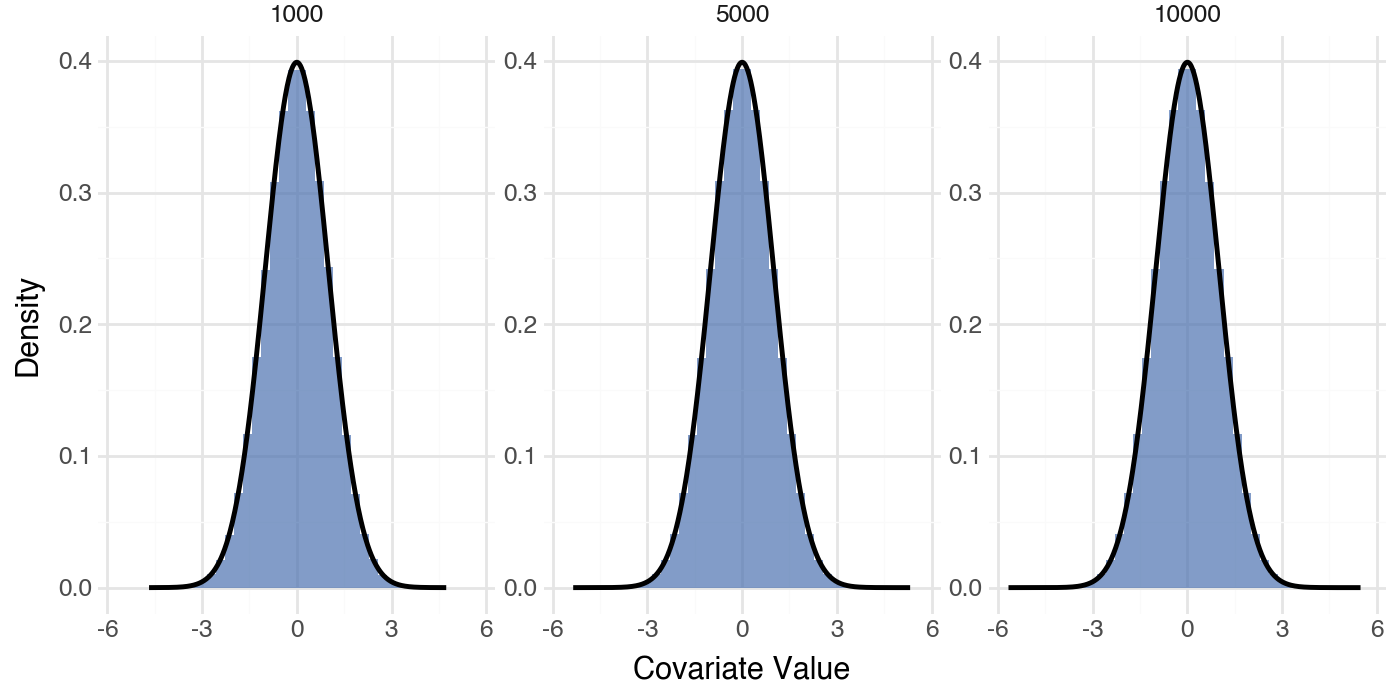

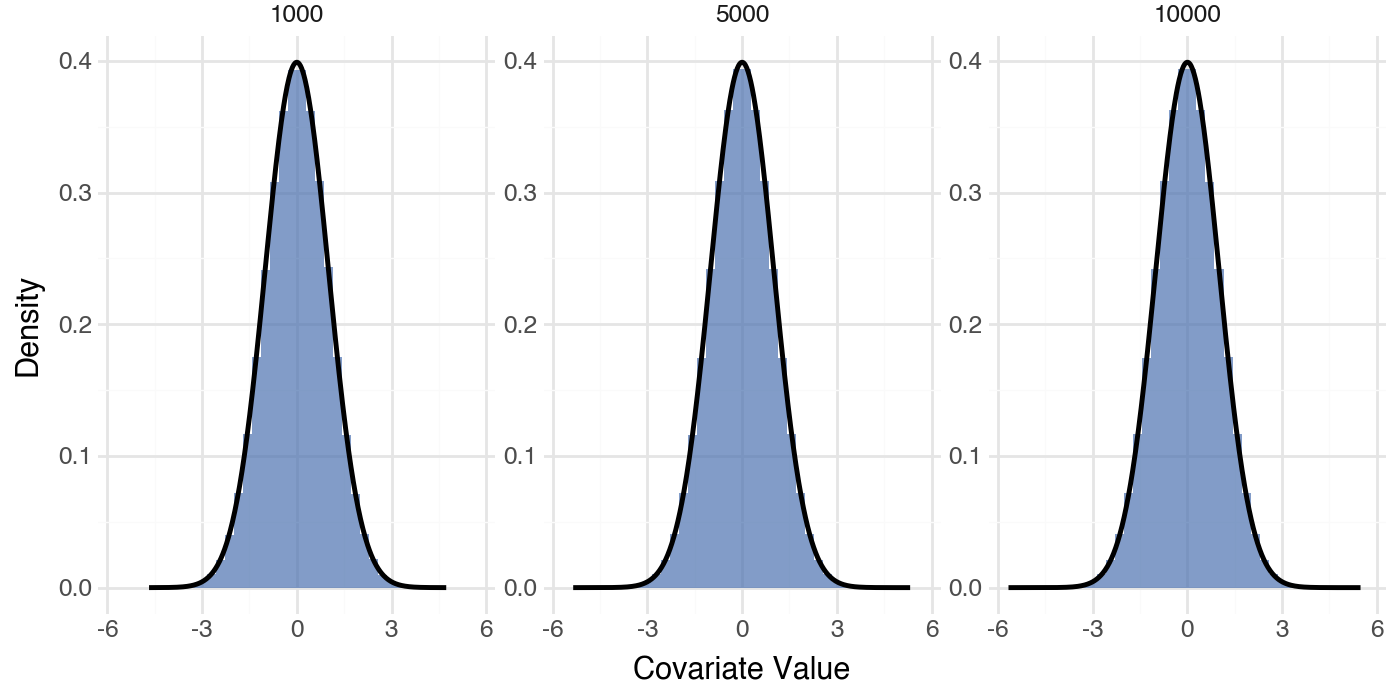

In [36]:
covariate_distribution_plot(X_dict, save_path = "plots/EDA/covariate_distribution.pdf")

In [48]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, facet_wrap,
    scale_fill_gradient2, theme_minimal, labs, theme, element_blank
)
import os

def beta_sparsity_heatmap(beta_dict, save_path="plots/EDA/beta_sparsity_heatmap.pdf"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rows = []
    for n, beta in beta_dict.items():
        beta = beta.flatten()
        p = len(beta)

        for idx in range(p):
            rows.append({
                "Index": idx + 1,
                "Row": 1,        # Dummy-Y-Achse
                "Beta": beta[idx],
                "n": int(n)
            })

    df = pd.DataFrame(rows)

    p = (
        ggplot(df, aes(x="Index", y="Row", fill="Beta"))
        + geom_tile()
        + scale_fill_gradient2(
            low="#4575b4", mid="white", high="#d73027",
            midpoint=0,
            name="Beta"
        )
        + facet_wrap("~ n", ncol=1, scales="free_x")
        + theme_minimal()
        + theme(
            figure_size=(7, 3.5),
            axis_text_y=element_blank(),
            axis_ticks_major_y=element_blank(),
            axis_title_y=element_blank()
        )
        + labs(x="Coefficient Index", y="")
    )

    display(p)
    p.save(save_path, dpi=300)

    return p


In [60]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_line, facet_wrap,
    theme_minimal, labs, theme
)
import os

def beta_sorted_plot(beta_dict, save_path="plots/EDA/beta_sorted_plot.pdf"):
    """
    beta_dict: dict with keys '1000', '5000', '10000'
               and values being the corresponding beta vectors.
    """

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rows = []
    for n, beta in beta_dict.items():
        beta = beta.flatten()
        beta_sorted = np.sort(beta)  # Betrag sortieren
        p = len(beta_sorted)

        for rank in range(p):
            rows.append({
                "Rank": rank + 1,
                "AbsBeta": beta_sorted[rank],
                "n": int(n)
            })

    df = pd.DataFrame(rows)

    p = (
        ggplot(df, aes(x="Rank", y="AbsBeta"))
        + geom_line(color="#4C72B0", size=0.6)
        + facet_wrap("~ n", scales="free_x")
        + theme_minimal()
        + theme(figure_size=(7, 3.5))
        + labs(
            x="Sorted Coefficient Rank",
            y="|Beta|"
        )
    )


    display(p)
    p.save(save_path, dpi=300)

    return p


In [74]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_histogram, geom_line,
    facet_wrap, theme_minimal, labs, theme
)
from scipy.stats import norm
import os

def beta_density_plot(beta_dict, bins=50, save_path="plots/EDA/beta_density_plot.pdf"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rows = []
    density_rows = []

    for n, beta in beta_dict.items():
        beta = beta.flatten()

        # Nur aktive Werte
        active = beta[beta != 0]

        # Histogram-Daten
        for val in active:
            rows.append({
                "Beta": val,
                "n": int(n)
            })

        # Normal-PDF für Vergleich
        x_min = min(active.min(), -4)
        x_max = max(active.max(), 4)
        x_vals = np.linspace(x_min, x_max, 500)

        pdf_vals = norm.pdf(x_vals, loc=0, scale=1)

        for xv, pv in zip(x_vals, pdf_vals):
            density_rows.append({
                "x": xv,
                "pdf": pv,
                "n": int(n)
            })

    df = pd.DataFrame(rows)
    density_df = pd.DataFrame(density_rows)

    p = (
        ggplot(df, aes("Beta"))
        + geom_histogram(
            aes(y="..density.."),
            bins=bins,
            fill="#4C72B0",
            alpha=0.7,
            boundary=0
        )
        + geom_line(
            density_df,
            aes(x="x", y="pdf"),
            color="black",
            size=1.0
        )
        + facet_wrap("~ n")
        + theme_minimal()
        + theme(figure_size=(7, 3.5))
        + labs(x="Active Beta Values", y="Density")
    )

    display(p)
    p.save(save_path, dpi=300)

    return p


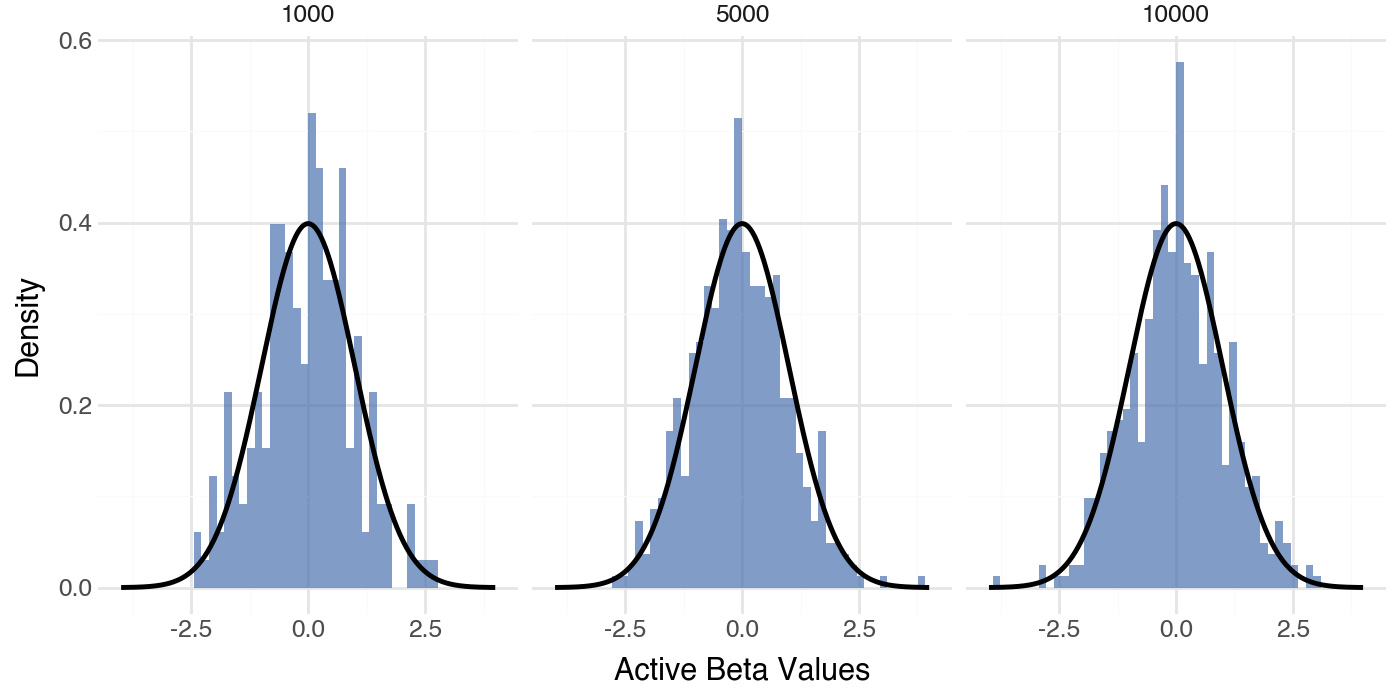

In [75]:
beta_dict = {
    "1000": pd.read_csv(f"{base}/Simulation Data/p1000_n1000/beta1.csv").to_numpy().flatten(),
    "5000": pd.read_csv(f"{base}/Simulation Data/p5000_n5000/beta1.csv").to_numpy().flatten(),
    "10000": pd.read_csv(f"{base}/Simulation Data/p10000_n10000/beta1.csv").to_numpy().flatten(),
}
p = beta_density_plot(beta_dict)

In [77]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_histogram, geom_line,
    facet_wrap, theme_minimal, labs, theme
)
from scipy.stats import norm
import os

def y_density_plot(y_dict, bins=40, save_path="plots/EDA/y_density_plot.pdf"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rows = []
    density_rows = []

    for n, y in y_dict.items():
        y = y.flatten()

        # Histogram-Daten
        for val in y:
            rows.append({
                "y": val,
                "n": int(n)
            })

        # Normal-PDF für Vergleich
        mu = np.mean(y)
        sigma = np.std(y)

        x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
        pdf_vals = norm.pdf(x_vals, loc=mu, scale=sigma)

        for xv, pv in zip(x_vals, pdf_vals):
            density_rows.append({
                "x": xv,
                "pdf": pv,
                "n": int(n)
            })

    df = pd.DataFrame(rows)
    density_df = pd.DataFrame(density_rows)

    p = (
        ggplot(df, aes("y"))
        + geom_histogram(
            aes(y="..density.."),
            bins=bins,
            fill="#4C72B0",
            alpha=0.7
        )
        + geom_line(
            density_df,
            aes(x="x", y="pdf"),
            color="black",
            size=1.0
        )
        + facet_wrap("~ n")
        + theme_minimal()
        + theme(figure_size=(7, 3.5))
        + labs(x="Response y", y="Density")
    )

    display(p)
    p.save(save_path, dpi=300)

    return p


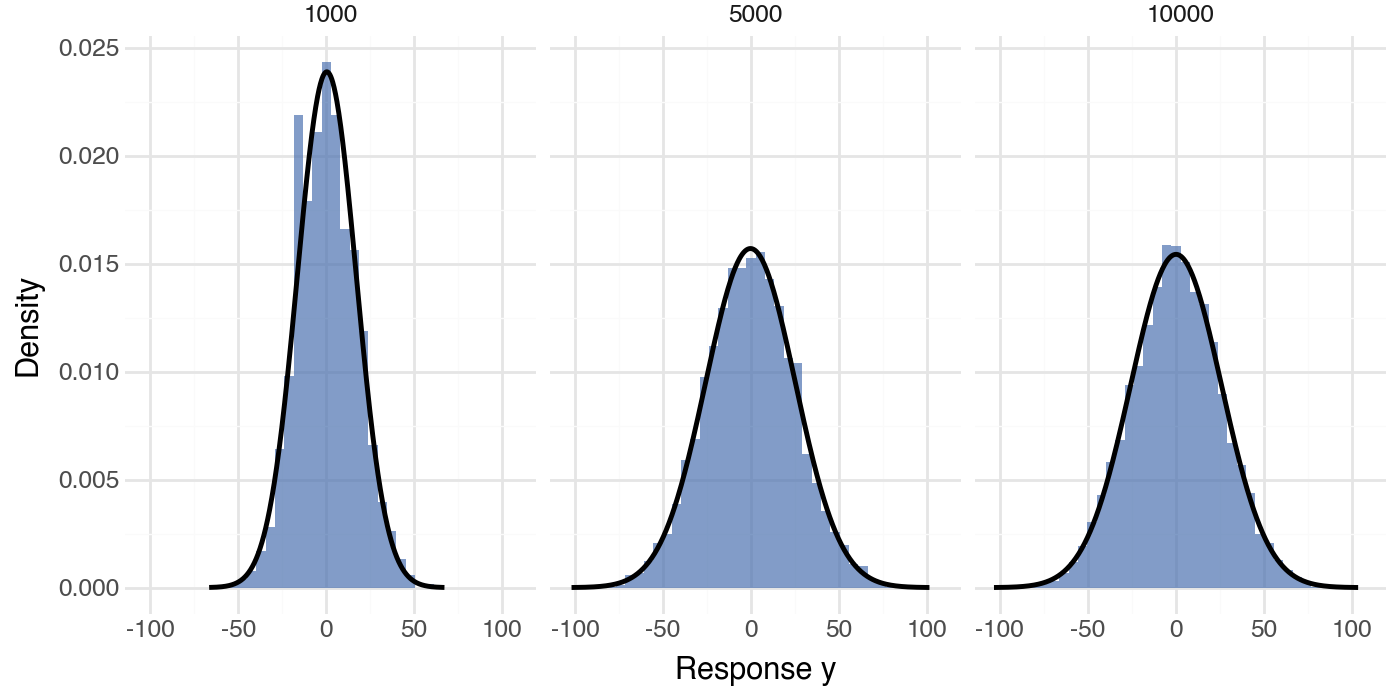

In [79]:
y_dict = {
    "1000": pd.read_csv(f"{base}/Simulation Data/p1000_n1000/y1.csv").to_numpy().flatten(),
    "5000": pd.read_csv(f"{base}/Simulation Data/p5000_n5000/y1.csv").to_numpy().flatten(),
    "10000": pd.read_csv(f"{base}/Simulation Data/p10000_n10000/y1.csv").to_numpy().flatten(),
}
p = y_density_plot(y_dict)